# Trabajo Practico N1: Modelo predictivo de tarifas de Uber
# Aprendizaje Automatizado 1 - TUIA - FCEIA
# Integrantes: Quinteros Facundo, Lazarte Manuel, Lasarte Roberto

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.linear_model import (LinearRegression, Lasso, Ridge, ElasticNet, RidgeCV, LassoCV, ElasticNetCV)

import warnings
warnings.filterwarnings('ignore')

## 1. Carga y exploracion inicial del dataset

In [2]:
data = pd.read_csv('uber_fares.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 13.7 MB


In [3]:
data.head(10)

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:50:00,8.47,2015-05-07 19:50:00 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:00:04,7.60,2009-07-17 20:00:04 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:49:07,12.65,2009-08-24 21:49:07 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:17:45,5.01,2009-06-26 08:17:45 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:46:18,15.64,2014-08-28 17:46:18 UTC,-73.925023,40.744085,-73.973082,40.761247,5
5,44470845,2011-02-12 02:28:47,4.05,2011-02-12 02:28:47 UTC,-73.969019,40.755910,-73.969019,40.755910,1
6,48725865,2014-10-12 07:01:25,26.73,2014-10-12 07:01:25 UTC,-73.961447,40.693965,-73.871195,40.774297,5
7,44195482,2012-12-11 13:53:11,2.70,2012-12-11 13:53:11 UTC,0.000000,0.000000,0.000000,0.000000,1
8,15822268,2012-02-17 09:34:14,9.50,2012-02-17 09:34:14 UTC,-73.975187,40.745767,-74.002720,40.743537,1
9,50611056,2012-03-29 19:03:22,12.53,2012-03-29 19:03:22 UTC,-74.001065,40.741787,-73.963040,40.775012,1


In [4]:
data.describe()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.362915,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.943248,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,1.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,5.970000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.430000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.660000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,503.130000,57.418457,1644.421482,1153.572603,872.697628,208.000000


### Observaciones iniciales del describe():
- fare_amount tiene un máximo muy alto (503.13), hay tarifas anomalas
- passenger_count tiene min 0 y un maximo imposiblelo, lo cual es invalido
- Las coordenadas tienen valores 0.0, lo cual indica registros erroneos (0,0 es el Golfo de Guinea)
- dropoff_longitude y dropoff_latitude tienen menos registros (199999 vs 200000), hay al menos un nulo

## 2. Analisis y tratamiento de datos faltantes

In [5]:
# Identificamos las filas con valores nulos
null_rows = data[data.isnull().any(axis=1)]
print(f"Filas con valores nulos: {len(null_rows)}")
print(f"Nulos por columna:\n{data.isnull().sum()}")
display(null_rows)

Filas con valores nulos: 1
Nulos por columna:
key                  0
date                 0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64


,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,2013-07-02 03:53:05,24.15,2013-07-02 03:53:05 UTC,-73.950581,40.779692,NaN,NaN,0


In [6]:
# Imputación de coordenadas faltantes o invalidas con KNN (n_neighbors=5).
# No eliminamos registros: marcamos como NaN las coordenadas problematicas
# (NaN originales, pares (0,0 y pares fuera del bounding box de NYC)
# y dejamos que KNNImputer las complete en base a filas con coordenadas similares.
cols_coords = ['pickup_longitude', 'pickup_latitude',
               'dropoff_longitude', 'dropoff_latitude']

n_nan_inicial = data[cols_coords].isnull().any(axis=1).sum()
print(f"Filas con NaN en coordenadas (antes): {n_nan_inicial}")

mask_pickup_00   = (data['pickup_longitude']  == 0) & (data['pickup_latitude']  == 0)
mask_dropoff_00  = (data['dropoff_longitude'] == 0) & (data['dropoff_latitude'] == 0)
mask_pickup_out  = ~data['pickup_latitude'].between(40.4, 41.0) | ~data['pickup_longitude'].between(-74.3, -73.7)
mask_dropoff_out = ~data['dropoff_latitude'].between(40.4, 41.0) | ~data['dropoff_longitude'].between(-74.3, -73.7)

data.loc[mask_pickup_00  | mask_pickup_out,  ['pickup_longitude',  'pickup_latitude']]  = np.nan
data.loc[mask_dropoff_00 | mask_dropoff_out, ['dropoff_longitude', 'dropoff_latitude']] = np.nan

n_nan_total = data[cols_coords].isnull().any(axis=1).sum()
print(f"Filas con coordenadas a imputar (NaN + (0,0) + fuera NYC): {n_nan_total}")

imputer = KNNImputer(n_neighbors=5)
data[cols_coords] = imputer.fit_transform(data[cols_coords])

print(f"Nulos restantes tras KNN: {data[cols_coords].isnull().sum().sum()}")
print(f"Filas totales (sin eliminar registros): {len(data)}")

Filas con NaN en coordenadas (antes): 1
Filas con coordenadas a imputar (NaN + (0,0) + fuera NYC): 4415
Nulos restantes tras KNN: 0
Filas totales (sin eliminar registros): 200000


In [7]:
percent = 4415 / 200000 * 100
print(f"Porcentaje de registros imputados: {percent:.2f}%")

Porcentaje de registros imputados: 2.21%


Se optó por utilizar KNNImputer en lugar de técnicas de imputación simples (como la media o la mediana) para preservar la estructura multivariante del conjunto de datos.

## 3. Analisis y tratamiento de datos atipicos

In [8]:
# Pasajeros invalidos (0, negativos, o valores imposibles >6): reemplazamos con la moda
print(f"Viajes con passenger_count <= 0: {(data['passenger_count'] <= 0).sum()}")
print(f"Viajes con passenger_count > 6: {(data['passenger_count'] > 6).sum()}")

moda_pasajeros = data[(data['passenger_count'] > 0) & (data['passenger_count'] <= 6)]['passenger_count'].mode()[0]
print(f"Moda de passenger_count (validos): {moda_pasajeros}")

data.loc[(data['passenger_count'] <= 0) | (data['passenger_count'] > 6), 'passenger_count'] = moda_pasajeros
print(f"Pasajeros invalidos despues de imputar: {((data['passenger_count'] <= 0) | (data['passenger_count'] > 6)).sum()}")

Viajes con passenger_count <= 0: 709
Viajes con passenger_count > 6: 1
Moda de passenger_count (validos): 1
Pasajeros invalidos despues de imputar: 0


En esta imputación se opto por reemplazar por la moda, ya que mas adelante se ve que la cantidad de pasajeros no presenta variabilidad de las tarifas

In [9]:
# Tarifas anómalas: análisis exploratorio
# La winsorización se aplicará DESPUÉS del train/test split para evitar data leakage.
print(f"Tarifas negativas: {(data['fare_amount'] < 0).sum()}")
print(f"Tarifas = 0: {(data['fare_amount'] == 0).sum()}")
print(f"Tarifas > 200: {(data['fare_amount'] > 200).sum()}")
print(f"Percentiles de fare_amount:")
print(data['fare_amount'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

Tarifas negativas: 0
Tarifas = 0: 0
Tarifas > 200: 6
Percentiles de fare_amount:
0.01     2.95
0.05     3.94
0.25     5.97
0.50     8.43
0.75    12.66
0.95    30.30
0.99    54.00
Name: fare_amount, dtype: float64


Se calculó los percentiles de las fare_amount para excluir los valores atípicos y que no influyan en los pasos siguientes.

## 4. Visualizacion de datos

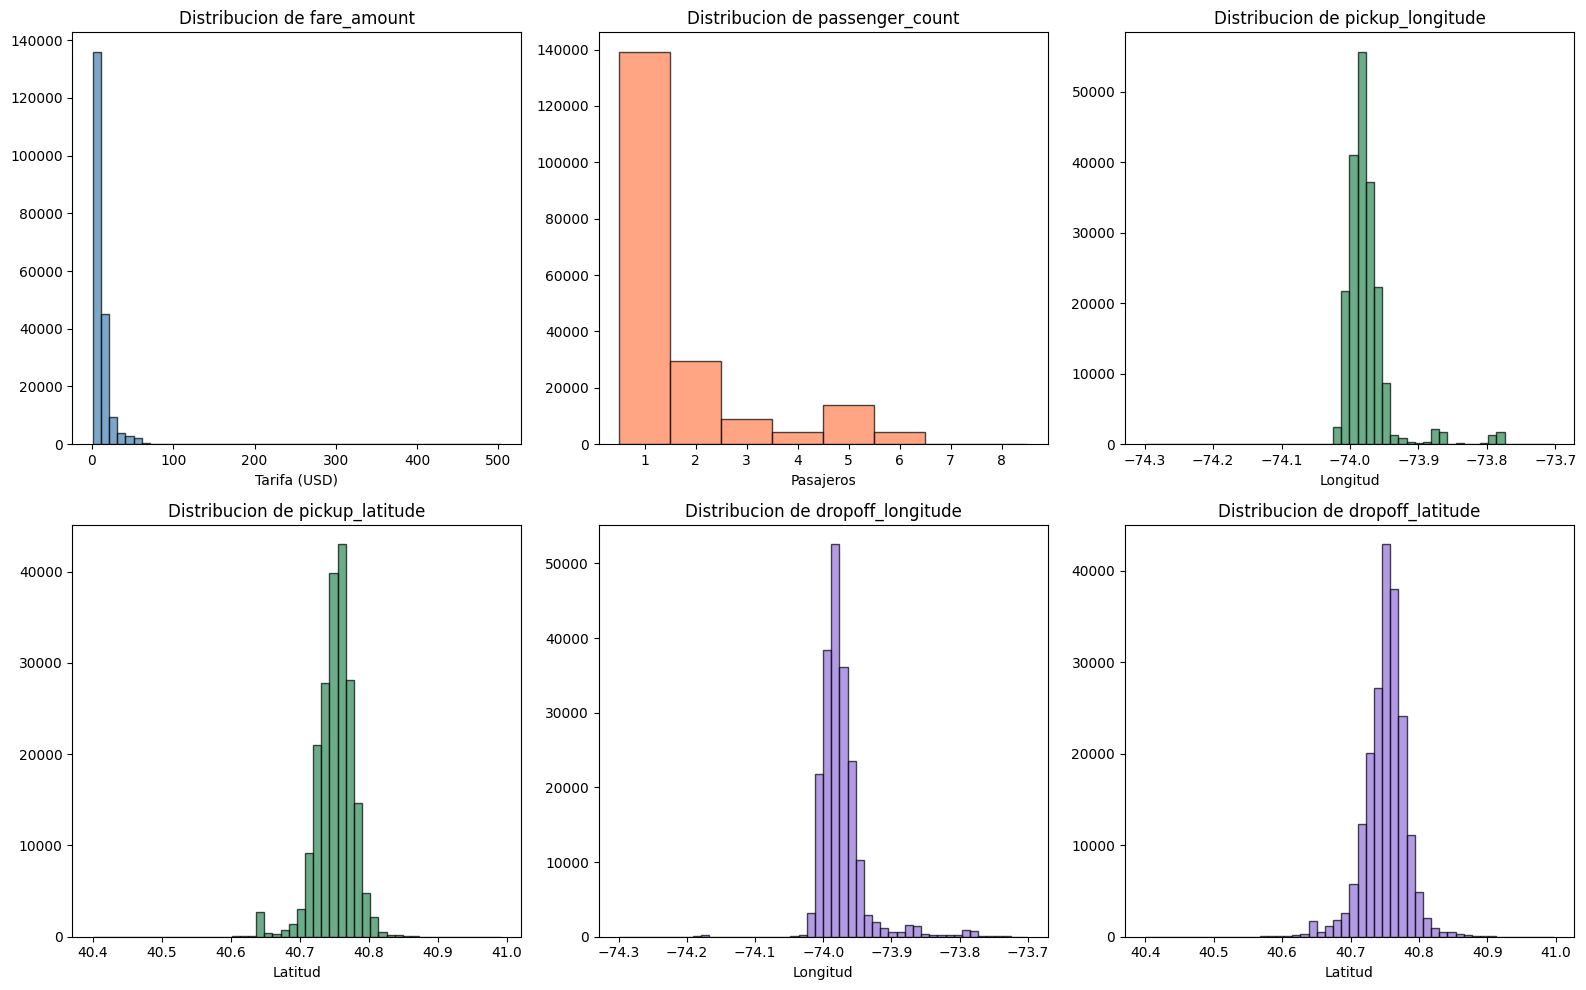

In [10]:
# Histogramas de las variables numericas principales
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].hist(data['fare_amount'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribucion de fare_amount')
axes[0, 0].set_xlabel('Tarifa (USD)')

axes[0, 1].hist(data['passenger_count'], bins=range(1, 10), color='coral', edgecolor='black', alpha=0.7, align='left')
axes[0, 1].set_title('Distribucion de passenger_count')
axes[0, 1].set_xlabel('Pasajeros')

axes[0, 2].hist(data['pickup_longitude'], bins=50, color='seagreen', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Distribucion de pickup_longitude')
axes[0, 2].set_xlabel('Longitud')

axes[1, 0].hist(data['pickup_latitude'], bins=50, color='seagreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribucion de pickup_latitude')
axes[1, 0].set_xlabel('Latitud')

axes[1, 1].hist(data['dropoff_longitude'], bins=50, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribucion de dropoff_longitude')
axes[1, 1].set_xlabel('Longitud')

axes[1, 2].hist(data['dropoff_latitude'], bins=50, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1, 2].set_title('Distribucion de dropoff_latitude')
axes[1, 2].set_xlabel('Latitud')

plt.tight_layout()
plt.show()

Realizamos gráficos de distribución para ver como se comportan las variables de nuestro dataset luego de la imputación de datos. Observamos tarifas desde 0 hasta casi 100 usd, pasajeros entre 1 y 6 (este caso podría ser un UberXL, no se clasificó porque no influye en la tarifa) y cómo se distribuyen la longitud y latitud.

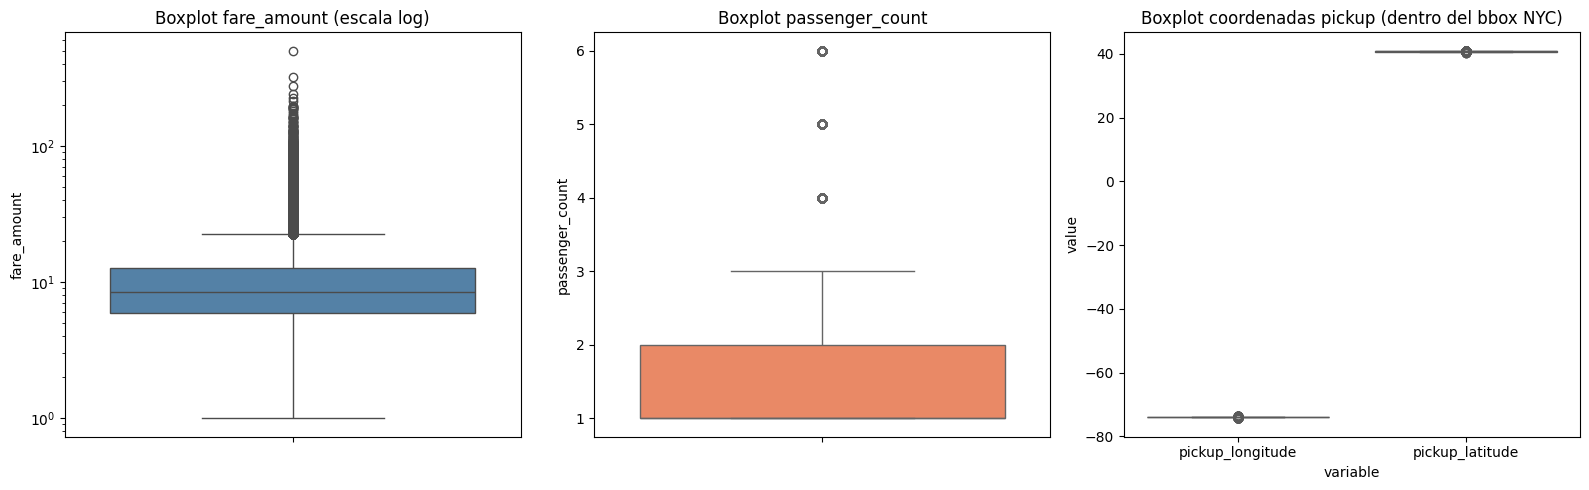

In [11]:
# Boxplots para visualizar outliers restantes (antes de winsorizar y_train)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(y=data['fare_amount'], ax=axes[0], color='steelblue')
axes[0].set_yscale('log')
axes[0].set_title('Boxplot fare_amount (escala log)')

sns.boxplot(y=data['passenger_count'], ax=axes[1], color='coral')
axes[1].set_title('Boxplot passenger_count')

coord_melt = pd.melt(data[['pickup_longitude', 'pickup_latitude']])
sns.boxplot(x='variable', y='value', data=coord_melt, ax=axes[2], palette='Set2')
axes[2].set_title('Boxplot coordenadas pickup (dentro del bbox NYC)')

plt.tight_layout()
plt.show()

## 5. Feature Engineering

Creamos nuevas variables que aporten informacion al modelo:
- **distancia_km**: distancia Manhattan entre pickup y dropoff (la variable mas relevante para predecir tarifa).
- **hora, dia_semana, mes, anio**: extraidas del pickup_datetime.
- **hora_sin, hora_cos, dia_semana_sin, dia_semana_cos, mes_sin, mes_cos**: encoding ciclico para que el modelo lineal capture la ciclicidad temporal.
- **mismo_origen_destino**: flag binario para viajes con pickup = dropoff (distancia 0).

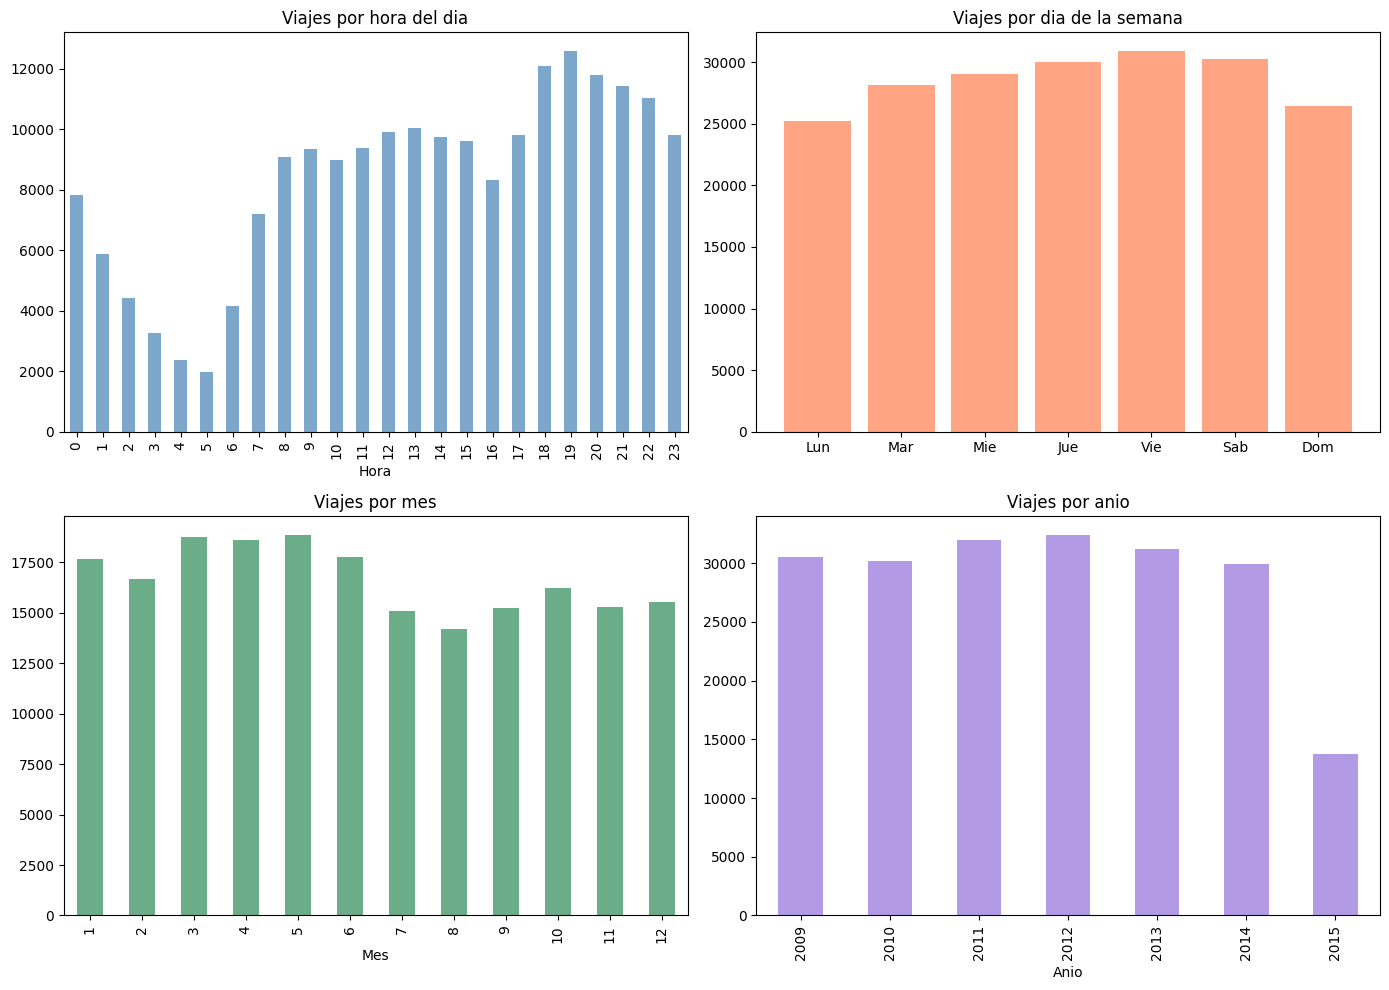

In [12]:
# Extraemos variables temporales y generamos encoding ciclico (sin/cos)
# para que el modelo lineal capture que hora=23 esta cerca de hora=0.
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'], format='mixed', utc=True)
data['hora']       = data['pickup_datetime'].dt.hour
data['dia_semana'] = data['pickup_datetime'].dt.dayofweek  # 0=Lunes, 6=Domingo
data['mes']        = data['pickup_datetime'].dt.month
data['anio']       = data['pickup_datetime'].dt.year

# Encoding ciclico: un modelo lineal no puede aprender ciclicidad de variables enteras, por eso se optó el encoding ciclico.
data['hora_sin']       = np.sin(2 * np.pi * data['hora'] / 24)
data['hora_cos']       = np.cos(2 * np.pi * data['hora'] / 24)
data['dia_semana_sin'] = np.sin(2 * np.pi * data['dia_semana'] / 7)
data['dia_semana_cos'] = np.cos(2 * np.pi * data['dia_semana'] / 7)
data['mes_sin']        = np.sin(2 * np.pi * data['mes'] / 12)
data['mes_cos']        = np.cos(2 * np.pi * data['mes'] / 12)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

data['hora'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue', alpha=0.7)
axes[0, 0].set_title('Viajes por hora del dia')
axes[0, 0].set_xlabel('Hora')

dias = ['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom']
conteo_dias = data['dia_semana'].value_counts().sort_index()
axes[0, 1].bar(dias, conteo_dias.values, color='coral', alpha=0.7)
axes[0, 1].set_title('Viajes por dia de la semana')

data['mes'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='seagreen', alpha=0.7)
axes[1, 0].set_title('Viajes por mes')
axes[1, 0].set_xlabel('Mes')

data['anio'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color='mediumpurple', alpha=0.7)
axes[1, 1].set_title('Viajes por anio')
axes[1, 1].set_xlabel('Anio')

plt.tight_layout()
plt.show()

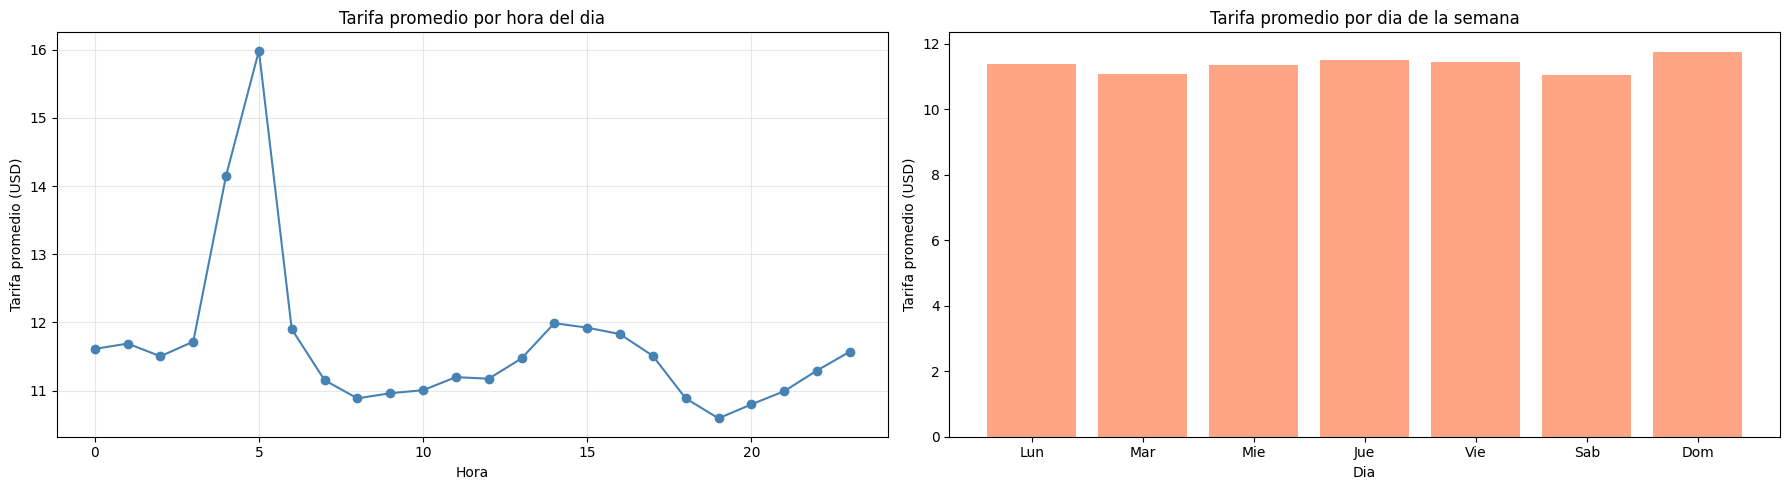

In [13]:
# Creamos figura con 2 graficos
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Tarifa promedio por hora
tarifa_hora = data.groupby('hora')['fare_amount'].mean()

axes[0].plot(
    tarifa_hora.index,
    tarifa_hora.values,
    'o-',
    color='steelblue'
)

axes[0].set_title('Tarifa promedio por hora del dia')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Tarifa promedio (USD)')
axes[0].grid(True, alpha=0.3)

# Tarifa promedio por dia de semana
tarifa_dia = data.groupby('dia_semana')['fare_amount'].mean()

dias = ['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom']

axes[1].bar(
    dias,
    tarifa_dia.values,
    color='coral',
    alpha=0.7
)

axes[1].set_title('Tarifa promedio por dia de la semana')
axes[1].set_xlabel('Dia')
axes[1].set_ylabel('Tarifa promedio (USD)')


plt.tight_layout()
plt.show()

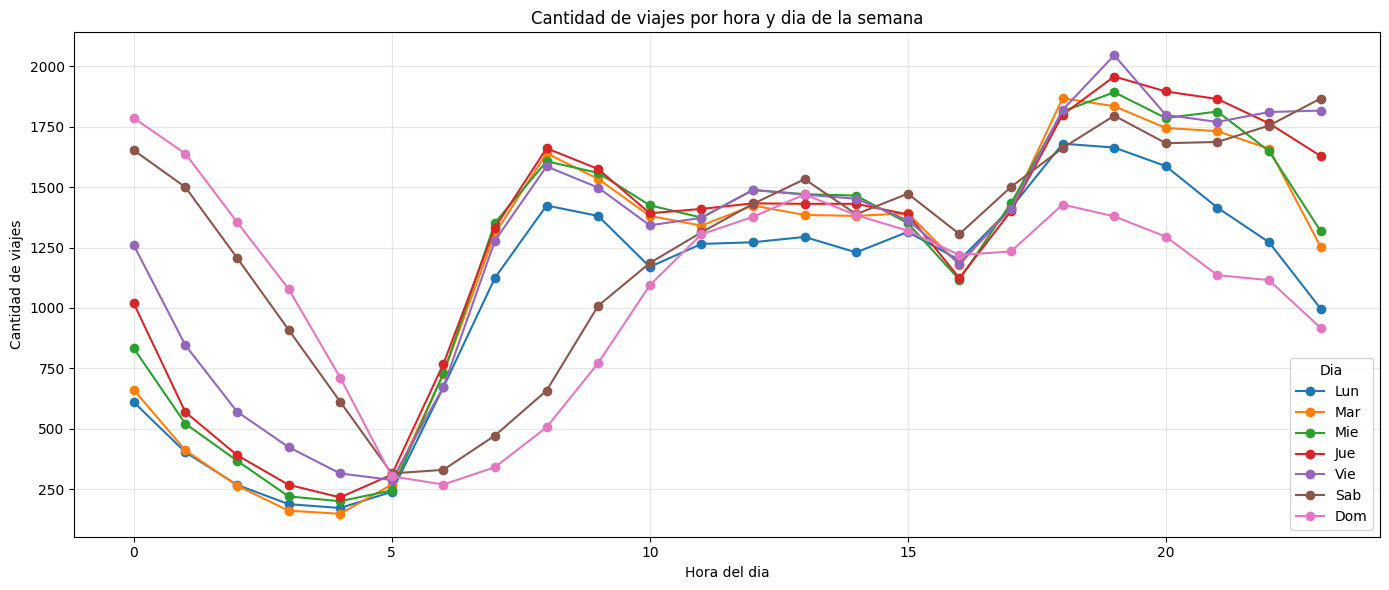

In [14]:
# Conteo de viajes por hora y dia
viajes_hora_dia = (
    data.groupby(['dia_semana', 'hora'])
    .size()
    .unstack(fill_value=0)
)

dias = ['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom']

fig, ax = plt.subplots(figsize=(14,6))

for i in range(7):
    ax.plot(
        viajes_hora_dia.columns,
        viajes_hora_dia.loc[i],
        marker='o',
        label=dias[i]
    )

ax.set_title('Cantidad de viajes por hora y dia de la semana')
ax.set_xlabel('Hora del dia')
ax.set_ylabel('Cantidad de viajes')
ax.legend(title='Dia')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Distancia Manhattan en km entre pickup y dropoff.
# Los taxis de NYC se mueven por la grilla de calles, no en linea recta,
# asi que la distancia Manhattan correlaciona mejor con la tarifa real
# que la Haversine (que mide con la curvatura de la tierra).
def manhattan_km(lon1, lat1, lon2, lat2):
    # 1 grado de latitud ~ 111 km. Para longitud, el factor depende de la latitud.
    lat_km = 111.0
    lon_km = 111.0 * np.cos(np.radians((lat1 + lat2) / 2))
    return np.abs(lat2 - lat1) * lat_km + np.abs(lon2 - lon1) * lon_km

data['distancia_km'] = manhattan_km(
    data['pickup_longitude'], data['pickup_latitude'],
    data['dropoff_longitude'], data['dropoff_latitude']
)

print(f"Distancia - min: {data['distancia_km'].min():.2f} km, max: {data['distancia_km'].max():.2f} km, media: {data['distancia_km'].mean():.2f} km")

Distancia - min: 0.00 km, max: 49.66 km, media: 4.18 km


In [16]:
# Detectar viajes con distancia igual a 0 km
mismo_od = data['distancia_km'] == 0
data['mismo_origen_destino'] = mismo_od.astype(int)
print(f"Viajes con distancia igual a 0 km: {data['mismo_origen_destino'].sum()}")

Viajes con distancia igual a 0 km: 1963


In [17]:
percent = 1963 / 200000 * 100
print(f"Porcentaje de viajes con distancia 0: {percent:.2f}%")

Porcentaje de viajes con distancia 0: 0.98%


Se optó por hacer un flag para estos viajes, ya que una persona puede pedir un viaje, ir a un destino X y volver a su origen.

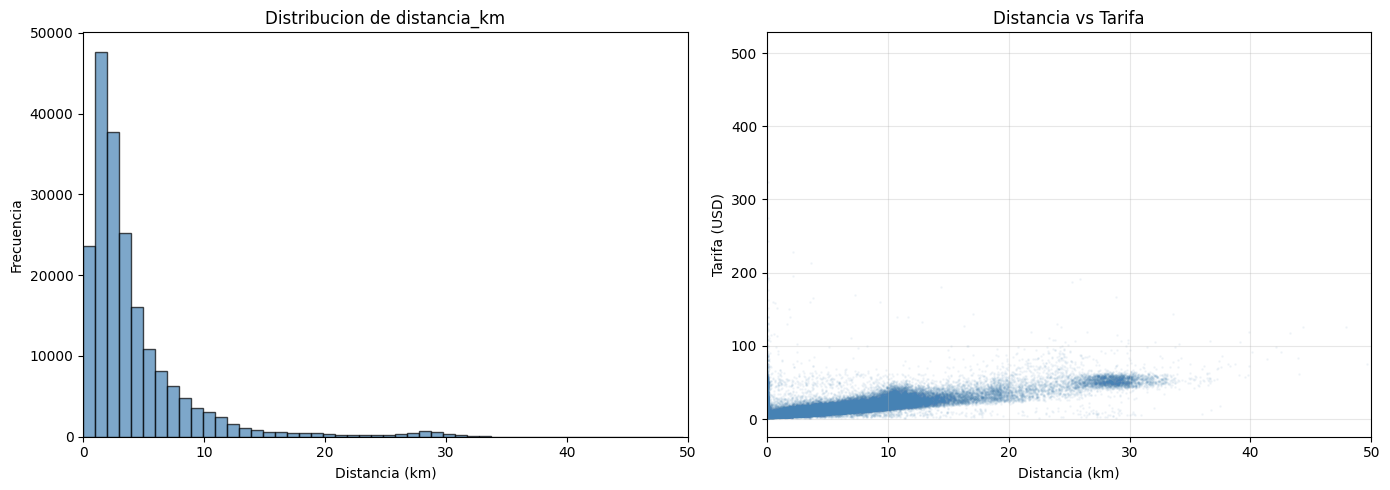

In [18]:
# Distribucion de distancia_km y su relacion con la tarifa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data['distancia_km'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribucion de distancia_km')
axes[0].set_xlabel('Distancia (km)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xlim(0, 50)

axes[1].scatter(data['distancia_km'], data['fare_amount'], alpha=0.05, s=1, color='steelblue')
axes[1].set_title('Distancia vs Tarifa')
axes[1].set_xlabel('Distancia (km)')
axes[1].set_ylabel('Tarifa (USD)')
axes[1].set_xlim(0, 50)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Seleccion de features: descartamos key (id), date (redundante), pickup_datetime (ya extrajimos componentes).
features = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
            'passenger_count',
            'hora_sin', 'hora_cos',
            'dia_semana_sin', 'dia_semana_cos',
            'mes_sin', 'mes_cos',
            'anio',
            'distancia_km', 'mismo_origen_destino']

df = data[features + ['fare_amount']].copy()
print(f"Shape del dataframe final: {df.shape}")
df.head()

Shape del dataframe final: (200000, 15)


,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hora_sin,hora_cos,dia_semana_sin,dia_semana_cos,mes_sin,mes_cos,anio,distancia_km,mismo_origen_destino,fare_amount
0,-73.999817,40.738354,-73.999512,40.723217,1,-0.965926,0.258819,0.433884,-0.900969,5.000000e-01,-0.866025,2015,1.705845,0,8.47
1,-73.994355,40.728225,-73.994710,40.750325,1,-0.866025,0.500000,-0.433884,-0.900969,-5.000000e-01,-0.866025,2009,2.482957,0,7.60
2,-74.005043,40.740770,-73.962565,40.772647,1,-0.707107,0.707107,0.000000,1.000000,-8.660254e-01,-0.500000,2009,7.109949,0,12.65
3,-73.976124,40.790844,-73.965316,40.803349,3,0.866025,-0.500000,-0.433884,-0.900969,1.224647e-16,-1.000000,2009,2.296253,0,5.01
4,-73.925023,40.744085,-73.973082,40.761247,5,-0.965926,-0.258819,0.433884,-0.900969,-8.660254e-01,-0.500000,2014,5.946087,0,15.64


## 6. Matriz de correlacion

Analizamos la correlacion entre las variables numericas. No descartamos automaticamente variables con alta correlacion, ya que la interaccion entre variables correlacionadas puede aportar informacion relevante al modelo.

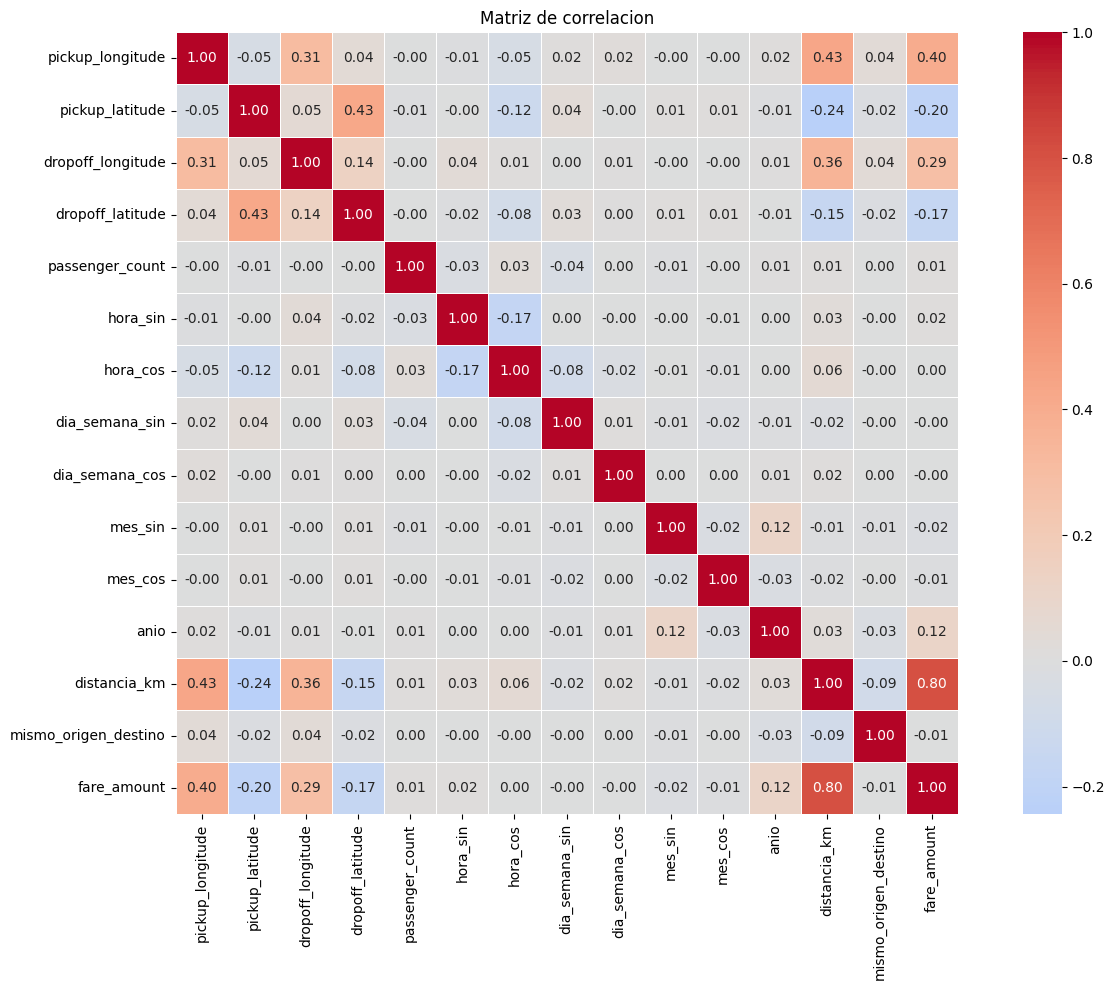


Correlacion con fare_amount:
fare_amount             1.000000
distancia_km            0.804532
pickup_longitude        0.402709
dropoff_longitude       0.286667
anio                    0.117863
hora_sin                0.015366
passenger_count         0.010391
hora_cos                0.001562
dia_semana_cos         -0.001079
dia_semana_sin         -0.002370
mismo_origen_destino   -0.005299
mes_cos                -0.007481
mes_sin                -0.017173
dropoff_latitude       -0.169466
pickup_latitude        -0.202790
Name: fare_amount, dtype: float64


In [20]:
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Matriz de correlacion')
plt.tight_layout()
plt.show()

print("\nCorrelacion con fare_amount:")
print(corr_matrix['fare_amount'].sort_values(ascending=False))

Como era de esperar, la distancia en km tiene una correlación intensa con la tarifa.

## 7. Division train-test y estandarizacion

Realizamos el split ANTES de estandarizar para evitar data leakage: el scaler se ajusta solo con datos de entrenamiento.

Calculamos metricas en train y test para detectar si hay overfitting (metricas mucho mejores en train) o underfitting (metricas malas en ambos).

In [21]:
# División train-test y estandarización
X = df[features]
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")

# Winsorización de la variable objetivo: límites calculados sobre y_train
p01 = y_train.quantile(0.01)
p99 = y_train.quantile(0.99)
print(f"Límites de winsorización (calculados sobre y_train): [{p01:.2f}, {p99:.2f}]")
y_train = y_train.clip(lower=p01, upper=p99)
y_test = y_test.clip(lower=p01, upper=p99)
print(f"Rango y_train post-winsorización: [{y_train.min():.2f}, {y_train.max():.2f}]")

# Estandarización: fit solo en train, transform en ambos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertimos a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

Train: 160000 muestras | Test: 40000 muestras
Límites de winsorización (calculados sobre y_train): [2.95, 54.02]
Rango y_train post-winsorización: [2.95, 54.02]


El dataset se dividió en 160.000 muestras para entrenamiento y 40.000 para prueba, permitiendo entrenar el modelo y luego evaluar su desempeño con datos no utilizados durante el entrenamiento. Posteriormente, se aplicó winsorización sobre la variable objetivo (y_train), estableciendo límites en 2.95 y 54.02 para reducir el impacto de valores atípicos. Como resultado, después de este proceso todos los valores de y_train quedaron dentro del rango [2.95, 54.02], lo que ayuda a mejorar la estabilidad y el rendimiento del modelo.

In [22]:
# Funciones auxiliares para metricas y residuos
def calcular_metricas(y_real, y_pred, nombre_conjunto):
    r2 = metrics.r2_score(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = root_mean_squared_error(y_real, y_pred)
    print(f"  {nombre_conjunto} -> R2: {r2:.4f} | RMSE: {rmse:.4f} | MSE: {mse:.4f}")
    return {'R2': r2, 'RMSE': rmse, 'MSE': mse}

def graficar_residuos(y_real, y_pred, titulo):
    residuos = np.asarray(y_real) - np.asarray(y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_pred, residuos, alpha=0.1, s=1, color='steelblue')
    axes[0].axhline(y=0, color='red', linestyle='--')
    axes[0].set_title(f'Residuos vs Predichos - {titulo}')
    axes[0].set_xlabel('Valores predichos')
    axes[0].set_ylabel('Residuos')
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(residuos, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[1].axvline(x=0, color='red', linestyle='--')
    axes[1].set_title(f'Distribucion de residuos - {titulo}')
    axes[1].set_xlabel('Residuos')

    plt.tight_layout()
    plt.show()

# Diccionario para guardar resultados de todos los modelos
resultados = {}

## 8. Regresion Lineal Multiple (LinearRegression)

Modelo base usando minimos cuadrados ordinarios. Calculamos metricas en train y en test para detectar overfitting/underfitting, y usamos validacion cruzada para tener una estimacion mas robusta del rendimiento.

LinearRegression:
  Train -> R2: 0.7428 | RMSE: 4.6107 | MSE: 21.2582
  Test -> R2: 0.7306 | RMSE: 4.7547 | MSE: 22.6075

  R2 CV (5-fold): 0.7427 (+/- 0.0072)


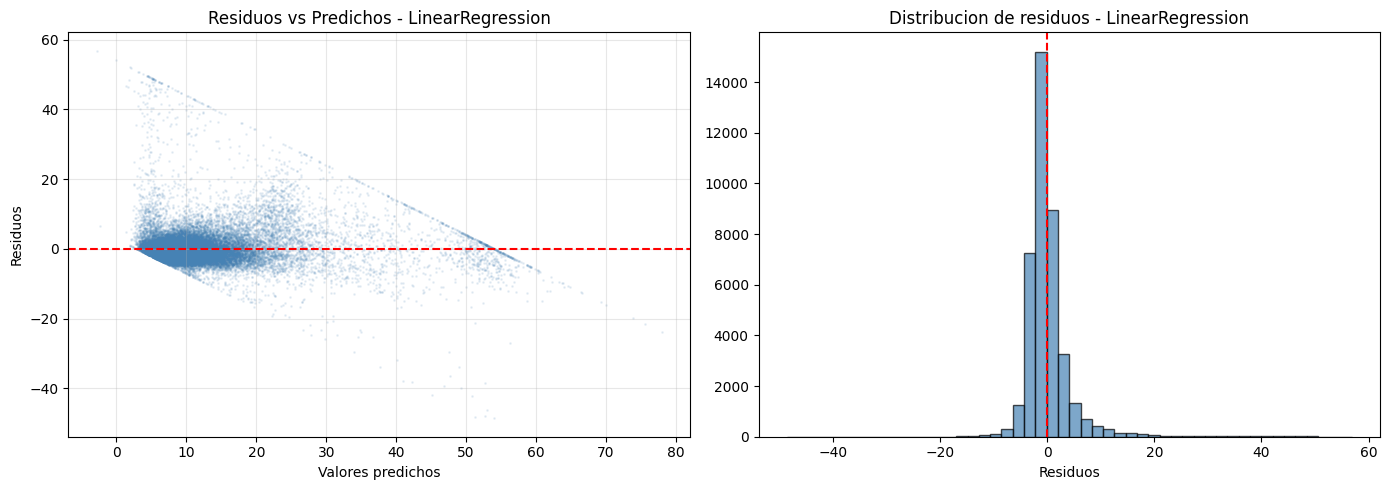

In [23]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_test_lr = lr.predict(X_test_scaled)

print("LinearRegression:")
res_train = calcular_metricas(y_train, y_pred_train_lr, "Train")
res_test = calcular_metricas(y_test, y_pred_test_lr, "Test")
resultados['LinearRegression'] = res_test

# Validacion cruzada 5-fold
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"\n  R2 CV (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

graficar_residuos(y_test, y_pred_test_lr, 'LinearRegression')

Los resultados indican que el modelo de regresión lineal tiene un desempeño moderado, con un R² en train de 0.7428 y en test de 0.7306, lo que sugiere que explica una parte importante de la variabilidad pero aún deja error no explicado. Los errores (RMSE ≈ 4.6 en train y 4.75 en test) muestran un desempeño bastante similar entre entrenamiento y prueba, lo que indica que no hay sobreajuste fuerte. En los gráficos de residuos se observa que están centrados alrededor de 0, pero con cierta dispersión y patrón en forma de abanico, lo que sugiere que el modelo no captura completamente algunas relaciones no lineales y que el error aumenta en valores predichos más altos. Además, la distribución de residuos es aproximadamente normal pero con colas, lo que indica presencia de algunos errores grandes puntuales (Posiblemente por una falta de datos importantes en el dataset).

## 9. Gradiente Descendiente (implementacion manual)

Implementamos las tres variantes clasicas a mano con numpy para visualizar
la dinamica de convergencia. Todas parten desde pesos inicializados en cero.

1. **Batch GD**: gradiente sobre todo el dataset en cada iteracion (curva suave).
2. **Stochastic GD**: un solo ejemplo por iteracion (curva ruidosa).
3. **Mini-batch GD**: lotes de tamano fijo (compromiso entre los dos anteriores).

Al final comparamos las metricas contra `LinearRegression` (solucion cerrada).

In [24]:
# Batch Gradient Descent (implementacion manual, vectorizada con numpy)
def batch_gd(X, y, lr=0.05, epochs=200):
    X_b = np.c_[np.ones(len(X)), X]
    w = np.zeros(X_b.shape[1])
    losses = []
    n = len(y)
    for _ in range(epochs):
        y_hat = X_b @ w
        grad = (2 / n) * X_b.T @ (y_hat - y)
        w -= lr * grad
        losses.append(float(np.mean((X_b @ w - y) ** 2)))
    return w, losses

n_epochs_batch = 2000
X_train_arr = np.asarray(X_train_scaled)
X_test_arr  = np.asarray(X_test_scaled)
y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)

w_batch, losses_batch = batch_gd(X_train_arr, y_train_arr, lr=0.05, epochs=n_epochs_batch)

y_pred_train_batch = np.c_[np.ones(len(X_train_arr)), X_train_arr] @ w_batch
y_pred_test_batch  = np.c_[np.ones(len(X_test_arr)),  X_test_arr]  @ w_batch

print("Batch Gradient Descent:")
calcular_metricas(y_train, y_pred_train_batch, "Train")
res_test = calcular_metricas(y_test, y_pred_test_batch, "Test")
resultados['SGD Batch'] = res_test

Batch Gradient Descent:
  Train -> R2: 0.7428 | RMSE: 4.6107 | MSE: 21.2582
  Test -> R2: 0.7306 | RMSE: 4.7547 | MSE: 22.6075


In [25]:
# Stochastic Gradient Descent: una muestra por iteracion, con learning rate decreciente
def stochastic_gd(X, y, lr0=0.01, epochs=200, seed=42):
    rng = np.random.default_rng(seed)
    X_b = np.c_[np.ones(len(X)), X]
    w = np.zeros(X_b.shape[1])
    losses = []
    n = len(y)
    for t in range(epochs):
        lr = lr0 / (1 + t * 0.01)
        i = rng.integers(n)
        xi = X_b[i]
        yi = y[i]
        grad = 2 * xi * (xi @ w - yi)
        w -= lr * grad
        losses.append(float(np.mean((X_b @ w - y) ** 2)))
    return w, losses

n_epochs_sgd = 2000
w_sgd, losses_sgd = stochastic_gd(X_train_arr, y_train_arr, lr0=0.01, epochs=n_epochs_sgd)

y_pred_train_sgd = np.c_[np.ones(len(X_train_arr)), X_train_arr] @ w_sgd
y_pred_test_sgd  = np.c_[np.ones(len(X_test_arr)),  X_test_arr]  @ w_sgd

print("Stochastic Gradient Descent:")
calcular_metricas(y_train, y_pred_train_sgd, "Train")
res_test = calcular_metricas(y_test, y_pred_test_sgd, "Test")
resultados['SGD Stochastic'] = res_test

Stochastic Gradient Descent:
  Train -> R2: 0.7401 | RMSE: 4.6352 | MSE: 21.4853
  Test -> R2: 0.7279 | RMSE: 4.7788 | MSE: 22.8369


In [26]:
# Mini-batch Gradient Descent: lotes de batch_size muestras por iteracion
def minibatch_gd(X, y, lr=0.05, epochs=200, batch_size=64, seed=42):
    rng = np.random.default_rng(seed)
    X_b = np.c_[np.ones(len(X)), X]
    w = np.zeros(X_b.shape[1])
    losses = []
    n = len(y)
    for _ in range(epochs):
        idx = rng.choice(n, batch_size, replace=False)
        Xb = X_b[idx]
        yb = y[idx]
        y_hat = Xb @ w
        grad = (2 / batch_size) * Xb.T @ (y_hat - yb)
        w -= lr * grad
        losses.append(float(np.mean((X_b @ w - y) ** 2)))
    return w, losses

n_epochs_mb = 2000
w_mb, losses_mb = minibatch_gd(X_train_arr, y_train_arr, lr=0.05, epochs=n_epochs_mb, batch_size=64)

y_pred_train_mb = np.c_[np.ones(len(X_train_arr)), X_train_arr] @ w_mb
y_pred_test_mb  = np.c_[np.ones(len(X_test_arr)),  X_test_arr]  @ w_mb

print("Mini-batch Gradient Descent:")
calcular_metricas(y_train, y_pred_train_mb, "Train")
res_test = calcular_metricas(y_test, y_pred_test_mb, "Test")
resultados['SGD Mini-batch'] = res_test

Mini-batch Gradient Descent:
  Train -> R2: 0.7200 | RMSE: 4.8112 | MSE: 23.1475
  Test -> R2: 0.7086 | RMSE: 4.9454 | MSE: 24.4573


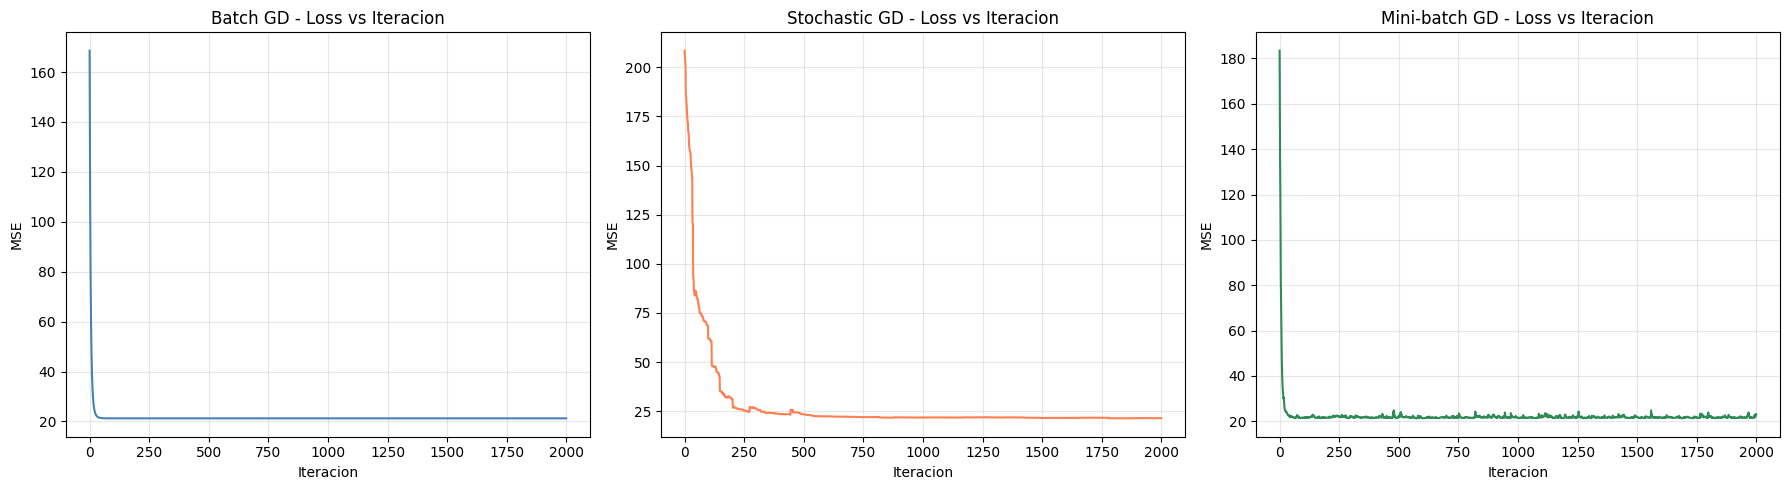

In [27]:
# Curvas de Loss vs Iteraciones para las 3 variantes de GD
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(range(n_epochs_batch), losses_batch, color='steelblue')
axes[0].set_title('Batch GD - Loss vs Iteracion')
axes[0].set_xlabel('Iteracion')
axes[0].set_ylabel('MSE')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(n_epochs_sgd), losses_sgd, color='coral')
axes[1].set_title('Stochastic GD - Loss vs Iteracion')
axes[1].set_xlabel('Iteracion')
axes[1].set_ylabel('MSE')
axes[1].grid(True, alpha=0.3)

axes[2].plot(range(n_epochs_mb), losses_mb, color='seagreen')
axes[2].set_title('Mini-batch GD - Loss vs Iteracion')
axes[2].set_xlabel('Iteracion')
axes[2].set_ylabel('MSE')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Observaciones sobre Gradiente Descendiente

- Las tres variantes arrancan con pesos en cero (MSE inicial alta) y convergen al mismo minimo global: el problema de regresion lineal con MSE es convexo.
- **Batch GD** muestra una curva suave y monotona: usa el gradiente exacto sobre todo el dataset en cada paso.
- **Stochastic GD** es visiblemente ruidoso: la estimacion del gradiente a partir de un solo ejemplo tiene alta varianza. Igual converge en promedio, con learning rate decreciente.
- **Mini-batch GD** equilibra las dos cosas: menos ruido que SGD y mas rapido que Batch por iteracion en datasets grandes.
- Que los tres lleguen a metricas finales casi identicas (R2, RMSE) no es casualidad: es consecuencia de la convexidad, lo que cambia es la trayectoria y la velocidad de convergencia, no la solucion final.
- La estandarizacion previa (StandardScaler) es critica para que el learning rate funcione igual en todas las features.

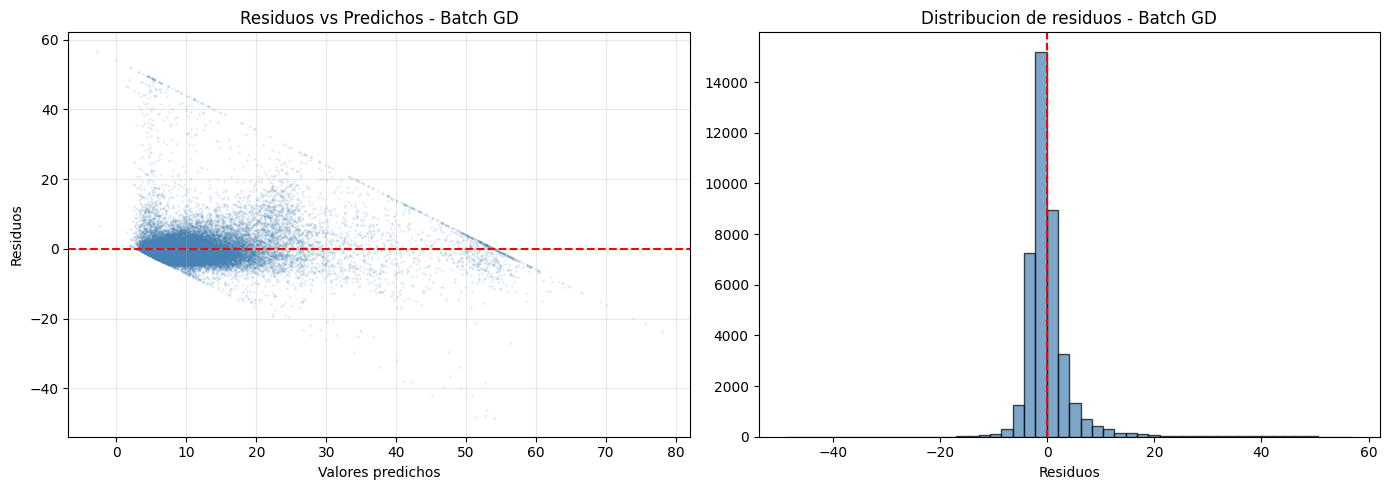

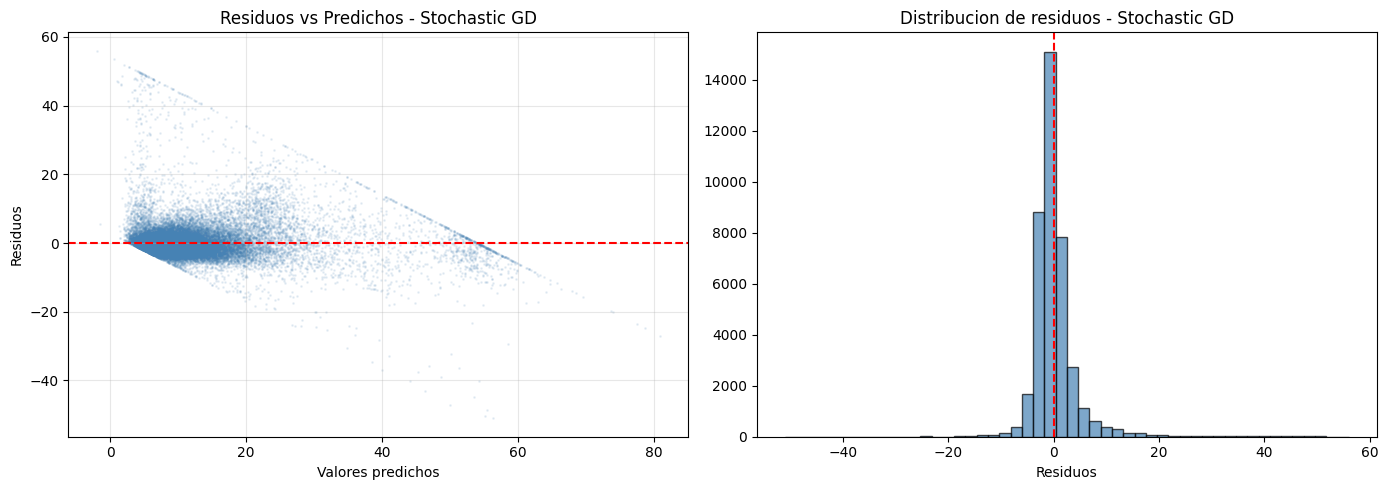

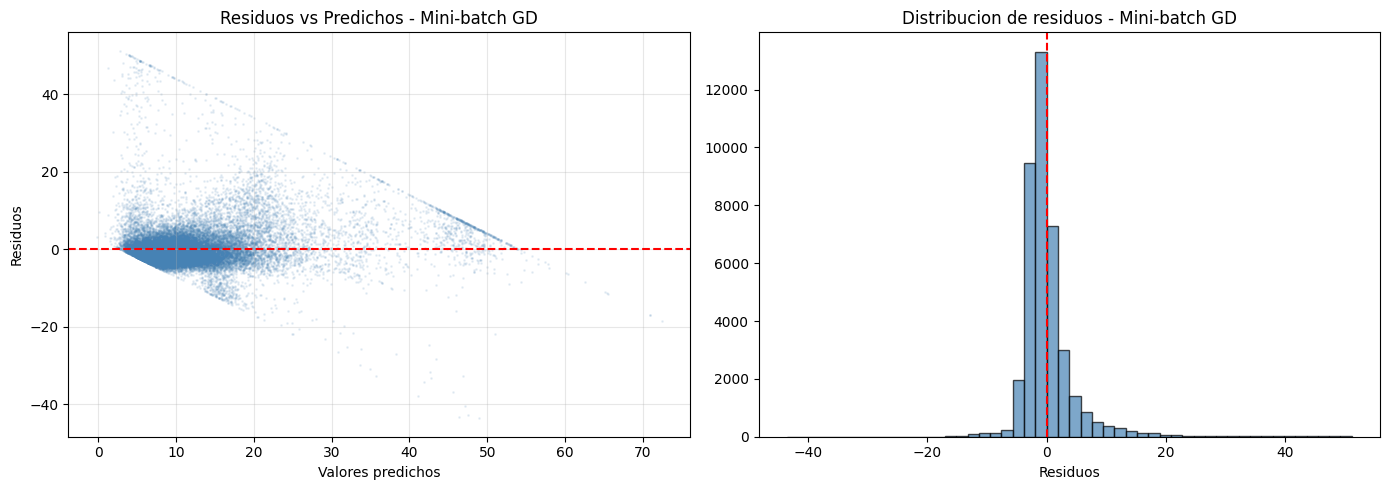

In [28]:
# Residuos de las 3 variantes de GD
graficar_residuos(y_test, y_pred_test_batch, 'Batch GD')
graficar_residuos(y_test, y_pred_test_sgd,   'Stochastic GD')
graficar_residuos(y_test, y_pred_test_mb,    'Mini-batch GD')

Los tres enfoques de gradiente descendiente logran resultados bastante parecidos en términos de calidad del ajuste, sin diferencias significativas en el comportamiento de los residuos.

## 10. Regularizacion: Lasso, Ridge, ElasticNet

Probamos modelos con penalizacion para analizar el efecto de la regularizacion:
- **Ridge (L2)**: penaliza coeficientes grandes, los reduce pero no los anula
- **Lasso (L1)**: puede anular coeficientes, actuando como seleccion de variables
- **ElasticNet**: combinacion de L1 y L2

Usamos RidgeCV, LassoCV y ElasticNetCV sobre un rango amplio de alpha (np.logspace(-4, 4, 50)) para encontrar el alpha optimo con validacion cruzada 5-fold.

In [29]:
# Usamos las versiones con CV integrada para encontrar el mejor alpha
alphas_cv = np.logspace(-4, 4, 50)

ridge_cv = RidgeCV(alphas=alphas_cv, cv=5)
ridge_cv.fit(X_train_scaled, y_train)
print(f"RidgeCV - Mejor alpha: {ridge_cv.alpha_:.6f}")

lasso_cv = LassoCV(alphas=alphas_cv, cv=5, max_iter=5000)
lasso_cv.fit(X_train_scaled, y_train)
print(f"LassoCV - Mejor alpha: {lasso_cv.alpha_:.6f}")

enet_cv = ElasticNetCV(alphas=alphas_cv, l1_ratio=0.5, cv=5, max_iter=5000)
enet_cv.fit(X_train_scaled, y_train)
print(f"ElasticNetCV - Mejor alpha: {enet_cv.alpha_:.6f}")

# Metricas de cada modelo con su mejor alpha
y_pred_train_ridge = ridge_cv.predict(X_train_scaled)
y_pred_test_ridge = ridge_cv.predict(X_test_scaled)
print("\nRidge (mejor alpha):")
calcular_metricas(y_train, y_pred_train_ridge, "Train")
res_test = calcular_metricas(y_test, y_pred_test_ridge, "Test")
resultados['Ridge'] = res_test

y_pred_train_lasso = lasso_cv.predict(X_train_scaled)
y_pred_test_lasso = lasso_cv.predict(X_test_scaled)
print("\nLasso (mejor alpha):")
calcular_metricas(y_train, y_pred_train_lasso, "Train")
res_test = calcular_metricas(y_test, y_pred_test_lasso, "Test")
resultados['Lasso'] = res_test

y_pred_train_enet = enet_cv.predict(X_train_scaled)
y_pred_test_enet = enet_cv.predict(X_test_scaled)
print("\nElasticNet (mejor alpha):")
calcular_metricas(y_train, y_pred_train_enet, "Train")
res_test = calcular_metricas(y_test, y_pred_test_enet, "Test")
resultados['ElasticNet'] = res_test

RidgeCV - Mejor alpha: 11.513954
LassoCV - Mejor alpha: 0.000100
ElasticNetCV - Mejor alpha: 0.000100

Ridge (mejor alpha):
  Train -> R2: 0.7428 | RMSE: 4.6107 | MSE: 21.2582
  Test -> R2: 0.7306 | RMSE: 4.7547 | MSE: 22.6075

Lasso (mejor alpha):
  Train -> R2: 0.7428 | RMSE: 4.6107 | MSE: 21.2582
  Test -> R2: 0.7306 | RMSE: 4.7547 | MSE: 22.6075

ElasticNet (mejor alpha):
  Train -> R2: 0.7428 | RMSE: 4.6107 | MSE: 21.2582
  Test -> R2: 0.7306 | RMSE: 4.7547 | MSE: 22.6075


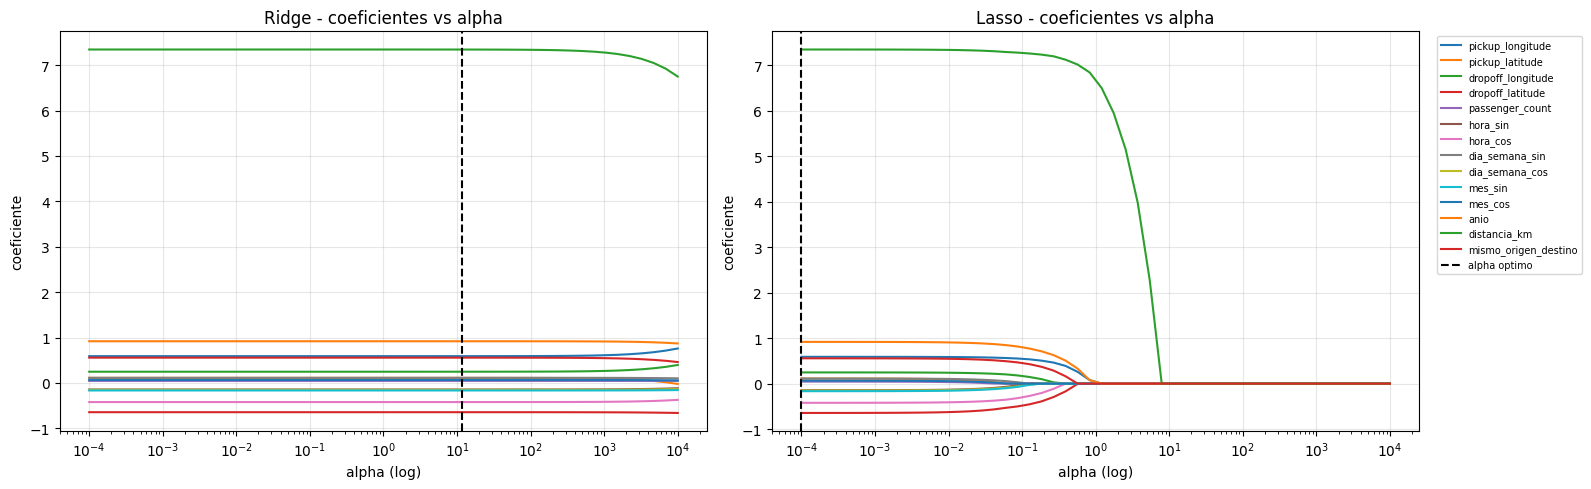

In [30]:
# Grafico de caminos de coeficientes para Ridge y Lasso:
# como cada coeficiente se encoge (Ridge) o se anula (Lasso) al aumentar alpha.
# La linea punteada vertical marca el alpha optimo elegido por CV.
alphas_path = np.logspace(-4, 4, 50)
ridge_coefs, lasso_coefs = [], []
for a in alphas_path:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    ridge_coefs.append(r.coef_)
    l = Lasso(alpha=a, max_iter=5000).fit(X_train_scaled, y_train)
    lasso_coefs.append(l.coef_)
ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, fname in enumerate(features):
    axes[0].plot(alphas_path, ridge_coefs[:, i], label=fname)
    axes[1].plot(alphas_path, lasso_coefs[:, i], label=fname)

axes[0].set_xscale('log')
axes[0].axvline(ridge_cv.alpha_, color='k', linestyle='--', label=f'alpha optimo')
axes[0].set_title('Ridge - coeficientes vs alpha')
axes[0].set_xlabel('alpha (log)')
axes[0].set_ylabel('coeficiente')
axes[0].grid(True, alpha=0.3)

axes[1].set_xscale('log')
axes[1].axvline(lasso_cv.alpha_, color='k', linestyle='--', label=f'alpha optimo')
axes[1].set_title('Lasso - coeficientes vs alpha')
axes[1].set_xlabel('alpha (log)')
axes[1].set_ylabel('coeficiente')
axes[1].grid(True, alpha=0.3)

axes[1].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

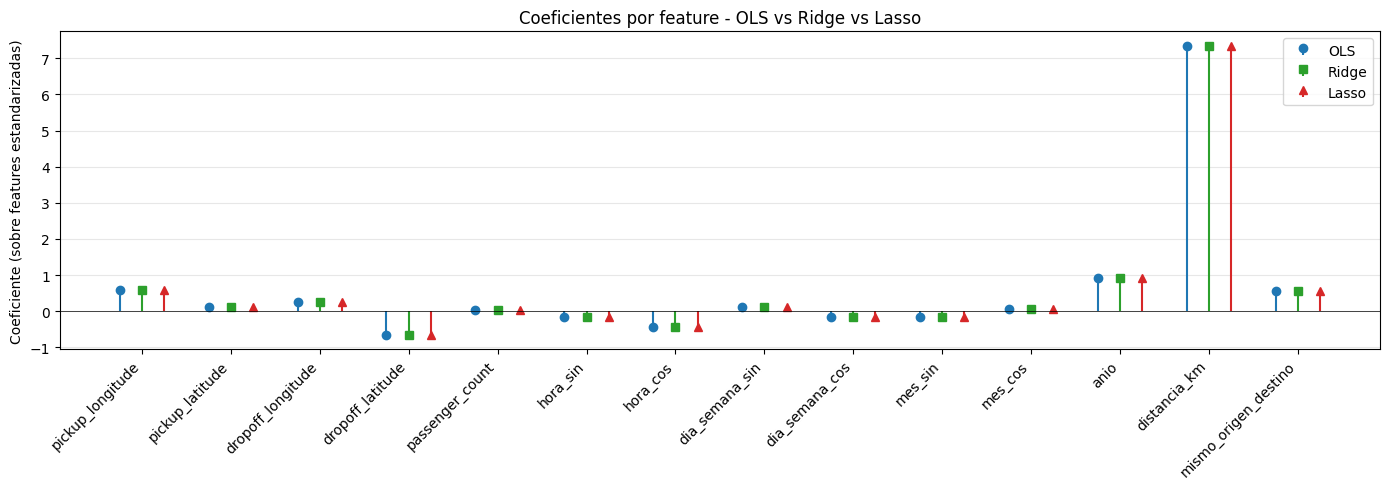

In [31]:
# Stem plot comparativo: que pesa cada feature en OLS vs Ridge vs Lasso.
# Util para leer rapido la 'firma' de cada modelo y ver que features anula Lasso.
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(features))
w = 0.25

ols_stems = ax.stem(x - w, lr.coef_, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='OLS')
rid_stems = ax.stem(x,     ridge_cv.coef_, linefmt='C2-', markerfmt='C2s', basefmt=' ', label='Ridge')
las_stems = ax.stem(x + w, lasso_cv.coef_, linefmt='C3-', markerfmt='C3^', basefmt=' ', label='Lasso')

ax.axhline(0, color='k', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.set_ylabel('Coeficiente (sobre features estandarizadas)')
ax.set_title('Coeficientes por feature - OLS vs Ridge vs Lasso')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

En este gráfico se observa que los coeficientes obtenidos por OLS, Ridge y Lasso son prácticamente iguales para todas las variables, lo que se evidencia en la alineación casi perfecta entre el círculo, el cuadrado y el triángulo en cada feature. Esto indica que la regularización aplicada no es lo suficientemente fuerte como para generar diferencias significativas, o bien, lo mas probable, que los datos no presentan problemas importantes como multicolinealidad; en consecuencia, los tres modelos terminan produciendo resultados muy similares.

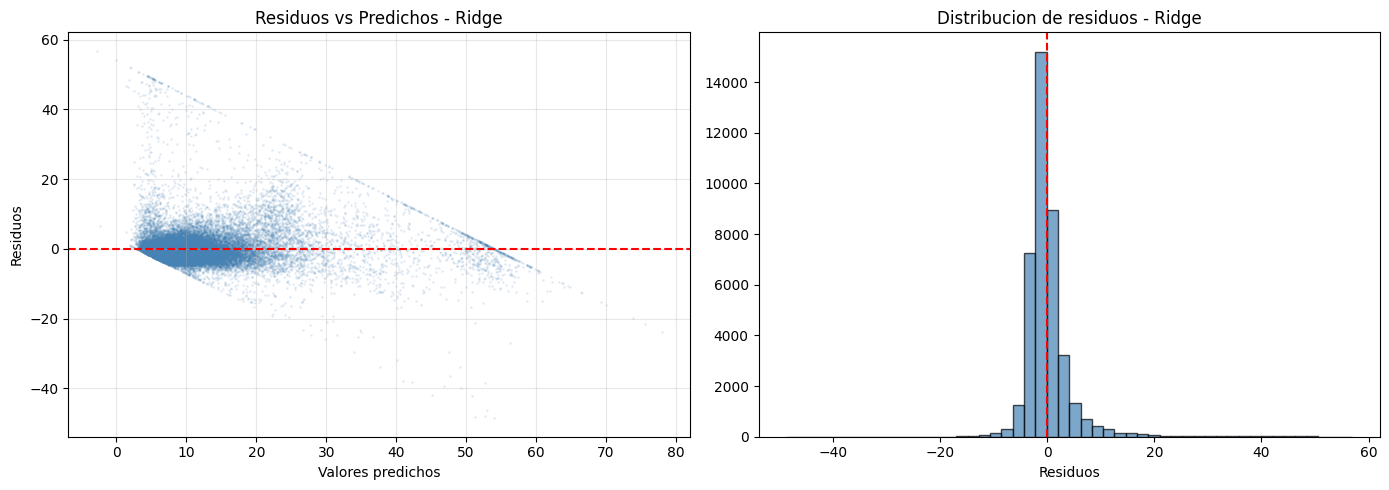

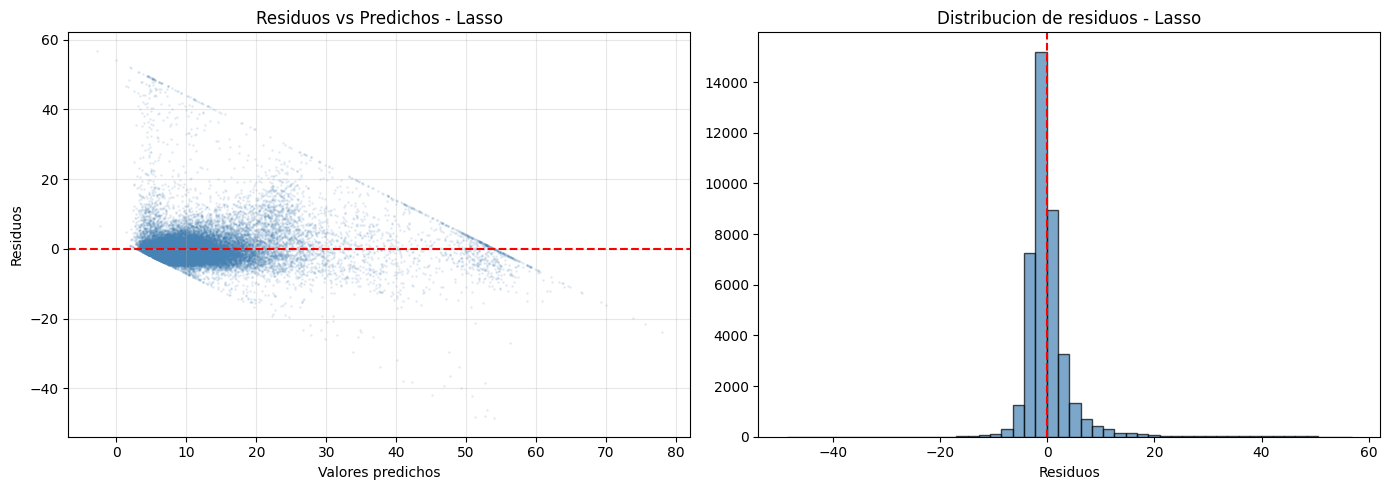

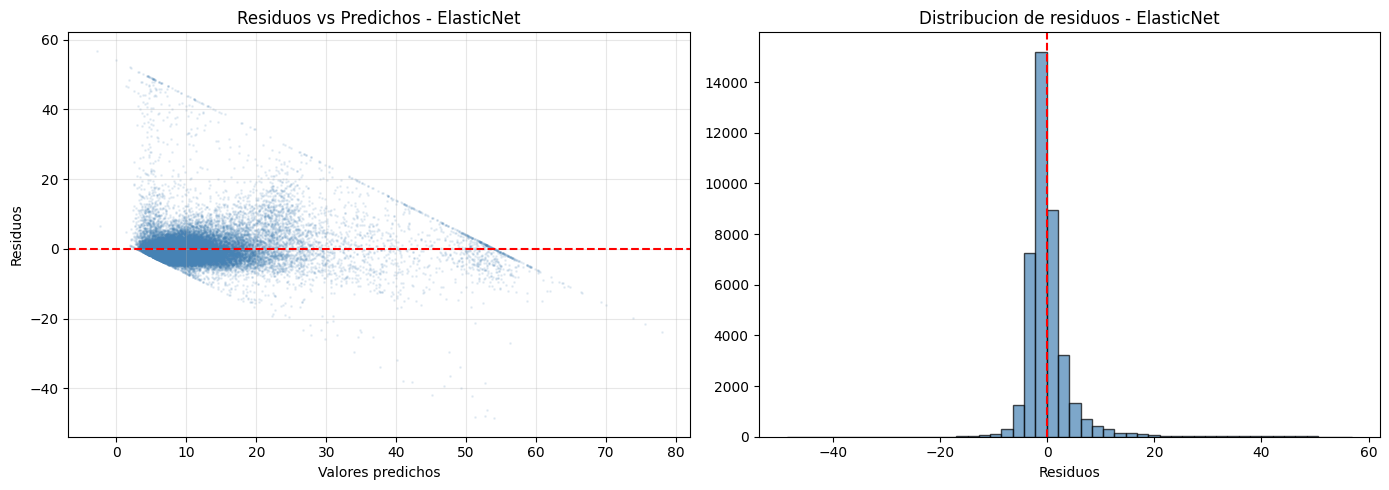

In [32]:
# Residuos de los modelos con regularizacion
graficar_residuos(y_test, y_pred_test_ridge, 'Ridge')
graficar_residuos(y_test, y_pred_test_lasso, 'Lasso')
graficar_residuos(y_test, y_pred_test_enet, 'ElasticNet')

In [33]:
# Coeficientes de Lasso: cuales variables se anularon?
coefs_lasso = pd.Series(lasso_cv.coef_, index=features)
print("Coeficientes de Lasso (variables anuladas tienen coef = 0):")
print(coefs_lasso.sort_values(ascending=False))
print(f"\nVariables anuladas por Lasso: {(coefs_lasso == 0).sum()} de {len(features)}")

Coeficientes de Lasso (variables anuladas tienen coef = 0):
distancia_km            7.344461
anio                    0.917537
pickup_longitude        0.589243
mismo_origen_destino    0.556381
dropoff_longitude       0.246497
dia_semana_sin          0.112457
pickup_latitude         0.111002
mes_cos                 0.064568
passenger_count         0.044119
hora_sin               -0.145021
dia_semana_cos         -0.152258
mes_sin                -0.166406
hora_cos               -0.421828
dropoff_latitude       -0.644734
dtype: float64

Variables anuladas por Lasso: 0 de 14


## 11. Optimizacion de hiperparametros

Variamos manualmente los hiperparametros del gradiente descendente (learning rate) y de Ridge/Lasso (alpha) para observar como cambia el desempeno.

In [34]:
# Variacion manual del learning rate en Batch GD
print("Variacion del learning rate en Batch GD (200 iteraciones)")
lrs = [0.001, 0.01, 0.05, 0.1]
for lr_val in lrs:
    w_tmp, _ = batch_gd(X_train_arr, y_train_arr, lr=lr_val, epochs=200)
    y_pred_tmp = np.c_[np.ones(len(X_test_arr)), X_test_arr] @ w_tmp
    rmse_tmp = root_mean_squared_error(y_test, y_pred_tmp)
    r2_tmp = metrics.r2_score(y_test, y_pred_tmp)
    print(f"  lr = {lr_val:<6} -> R2 test: {r2_tmp:.4f} | RMSE test: {rmse_tmp:.4f}")

print()

# Variacion manual del alpha en Ridge y Lasso
print("Variacion del alpha en Ridge")
alphas_manual = [0.001, 0.01, 0.1, 1, 10, 100]
for a in alphas_manual:
    modelo_r = Ridge(alpha=a)
    modelo_r.fit(X_train_scaled, y_train)
    rmse_r = root_mean_squared_error(y_test, modelo_r.predict(X_test_scaled))
    r2_r = modelo_r.score(X_test_scaled, y_test)
    print(f"  alpha = {a:<8} -> R2 test: {r2_r:.4f} | RMSE test: {rmse_r:.4f}")

print()

print("Variacion del alpha en Lasso")
for a in alphas_manual:
    modelo_l = Lasso(alpha=a, max_iter=5000)
    modelo_l.fit(X_train_scaled, y_train)
    rmse_l = root_mean_squared_error(y_test, modelo_l.predict(X_test_scaled))
    r2_l = modelo_l.score(X_test_scaled, y_test)
    n_cero = (modelo_l.coef_ == 0).sum()
    print(f"  alpha = {a:<8} -> R2 test: {r2_l:.4f} | RMSE test: {rmse_l:.4f} | features anuladas: {n_cero}")

Variacion del learning rate en Batch GD (200 iteraciones)
  lr = 0.001  -> R2 test: -0.1986 | RMSE test: 10.0301
  lr = 0.01   -> R2 test: 0.7260 | RMSE test: 4.7954
  lr = 0.05   -> R2 test: 0.7306 | RMSE test: 4.7547
  lr = 0.1    -> R2 test: 0.7306 | RMSE test: 4.7547

Variacion del alpha en Ridge
  alpha = 0.001    -> R2 test: 0.7306 | RMSE test: 4.7547
  alpha = 0.01     -> R2 test: 0.7306 | RMSE test: 4.7547
  alpha = 0.1      -> R2 test: 0.7306 | RMSE test: 4.7547
  alpha = 1        -> R2 test: 0.7306 | RMSE test: 4.7547
  alpha = 10       -> R2 test: 0.7306 | RMSE test: 4.7547
  alpha = 100      -> R2 test: 0.7306 | RMSE test: 4.7547

Variacion del alpha en Lasso
  alpha = 0.001    -> R2 test: 0.7306 | RMSE test: 4.7547 | features anuladas: 0
  alpha = 0.01     -> R2 test: 0.7306 | RMSE test: 4.7549 | features anuladas: 0
  alpha = 0.1      -> R2 test: 0.7292 | RMSE test: 4.7672 | features anuladas: 3
  alpha = 1        -> R2 test: 0.6945 | RMSE test: 5.0635 | features anuladas

### Observaciones sobre la optimizacion de hiperparametros

En Batch Gradient Descent, el learning rate influye mucho: con un valor muy bajo (0.001) el modelo no logra converger bien y el rendimiento es malo (R² negativo), mientras que a partir de 0.01 ya alcanza buenos resultados y luego se estabiliza, mostrando que hay un rango adecuado donde el algoritmo converge correctamente sin mejorar mucho más. En Ridge, prácticamente no hay cambios al variar α, lo que sugiere que la regularización no está teniendo un impacto relevante en este dataset (probablemente porque no hay fuerte multicolinealidad o los coeficientes ya son estables). En cambio, en Lasso sí se ve un efecto claro: con α bajos se comporta igual que OLS, pero al aumentar α comienza a anular variables (feature selection), lo que inicialmente casi no afecta el rendimiento, pero si se incrementa demasiado degrada notablemente el modelo hasta hacerlo inútil.

## 12. Comparacion de modelos

Comparacion de modelos (metricas en Test):



,R2,RMSE,MSE
Ridge,0.7306,4.7547,22.6075
ElasticNet,0.7306,4.7547,22.6075
LinearRegression,0.7306,4.7547,22.6075
SGD Batch,0.7306,4.7547,22.6075
Lasso,0.7306,4.7547,22.6075
SGD Stochastic,0.7279,4.7788,22.8369
SGD Mini-batch,0.7086,4.9454,24.4573


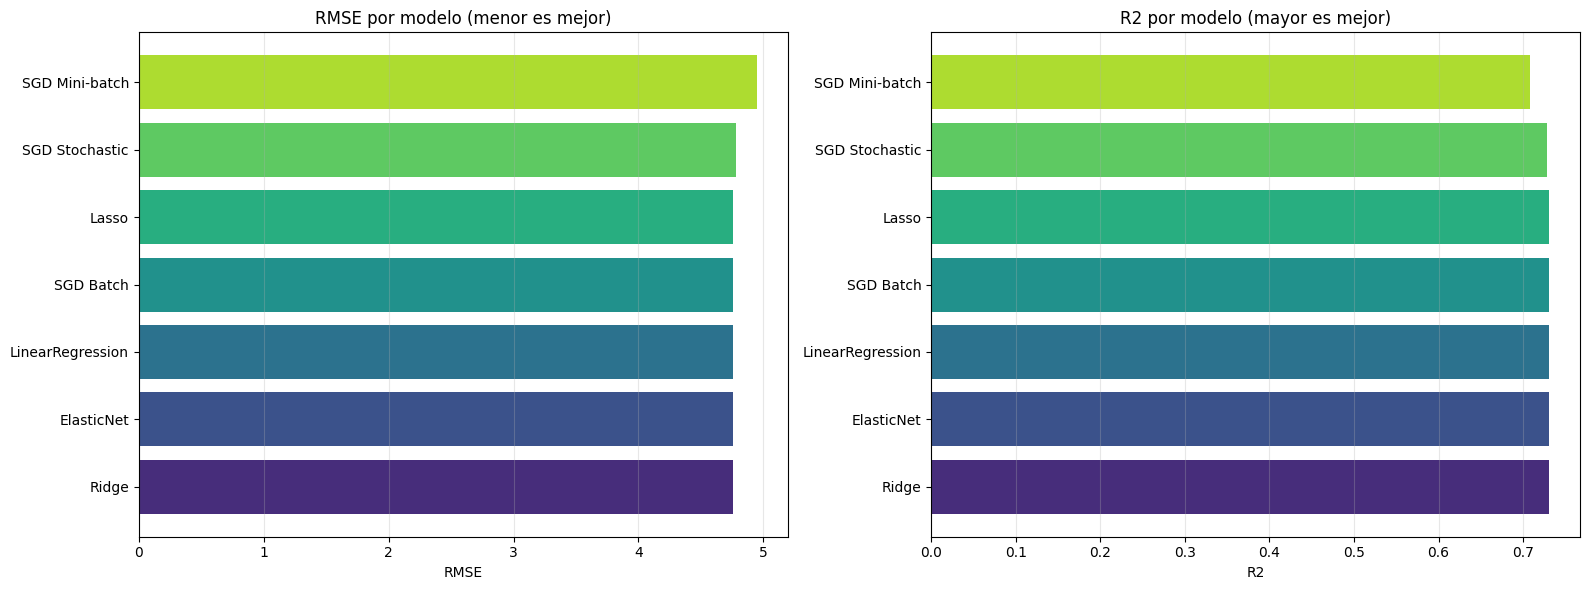


Mejor modelo segun RMSE: Ridge (RMSE = 4.7547)


In [35]:
# Tabla comparativa de todos los modelos
df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.sort_values('RMSE')
print("Comparacion de modelos (metricas en Test):\n")
display(df_resultados.round(4))

# Grafico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colores = sns.color_palette('viridis', len(df_resultados))

axes[0].barh(df_resultados.index, df_resultados['RMSE'], color=colores)
axes[0].set_title('RMSE por modelo (menor es mejor)')
axes[0].set_xlabel('RMSE')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(df_resultados.index, df_resultados['R2'], color=colores)
axes[1].set_title('R2 por modelo (mayor es mejor)')
axes[1].set_xlabel('R2')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

mejor_modelo = df_resultados['RMSE'].idxmin()
print(f"\nMejor modelo segun RMSE: {mejor_modelo} (RMSE = {df_resultados.loc[mejor_modelo, 'RMSE']:.4f})")

## 13. Conclusion

Como se vió hasta ahora, los resultados muestran que todos los modelos están rindiendo de manera muy similar, con valores de R² alrededor de 0.73 y RMSE cercanos a 4.75, lo que indica que el problema ya está bastante bien capturado independientemente del método. Los modelos lineales clásicos (OLS, Ridge, ElasticNet) prácticamente no difieren, lo cual coincide con lo visto antes: la regularización no aporta mejoras significativas porque los datos no presentan grandes problemas de multicolinealidad ni sobreajuste. Lasso logra un desempeño comparable mientras α es bajo, pero cuando aumenta empieza a perder calidad al eliminar demasiadas variables. En cuanto a los métodos iterativos (SGD Batch, Stochastic y Mini-batch), también alcanzan resultados muy similares cuando el learning rate es adecuado, aunque Mini-batch queda levemente por detrás. En síntesis, no hay un claro "ganador", y la elección del modelo puede basarse más en simplicidad o interpretabilidad que en performance, siendo OLS o Ridge opciones sólidas y estables para este caso.